# Stage 08 — Cross-Method XAI Evaluation

This notebook compares the final persisted SHAP, LIME and DiCE results for the fixed 20-case German Credit cohort. It is evaluation-only and does not regenerate explanations or alter the frozen modelling workflow.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "german_credit":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]
elif PROJECT_ROOT.name == "ml":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "backend":
    PROJECT_ROOT = PROJECT_ROOT.parent

ARTIFACT_DIR = PROJECT_ROOT / "backend" / "artifacts" / "german_credit"
PLOT_DIR = ARTIFACT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Artifact inventory

The inventory checks every required persisted input before evaluation. Diagnostic DiCE setup archives are deliberately excluded.

In [2]:
required = {
    "xai_evaluation_cases.csv": "Fixed 20-case cohort",
    "model_metadata.json": "Frozen model metadata",
    "preprocessing_metadata.json": "Frozen preprocessing metadata",
    "shap_global_importance.csv": "SHAP global importance",
    "shap_local_explanations.csv": "SHAP local explanations",
    "shap_top_factors.csv": "SHAP top-five factors",
    "shap_sparsity_metrics.csv": "SHAP compactness metrics",
    "shap_preliminary_stability.csv": "SHAP stability diagnostic",
    "shap_preliminary_faithfulness.csv": "SHAP sensitivity diagnostic",
    "shap_metadata.json": "SHAP provenance",
    "lime_local_explanations.csv": "LIME local explanations",
    "lime_top_factors.csv": "LIME top-five factors",
    "lime_sparsity_metrics.csv": "LIME compactness metrics",
    "lime_preliminary_stability.csv": "LIME reproducibility diagnostic",
    "lime_preliminary_faithfulness.csv": "LIME sensitivity diagnostic",
    "lime_local_fidelity.csv": "LIME local fidelity",
    "lime_metadata.json": "LIME provenance",
    "dice_counterfactuals.csv": "Final valid DiCE counterfactuals",
    "dice_feature_changes.csv": "DiCE actionable changes",
    "dice_sparsity_metrics.csv": "DiCE sparsity metrics",
    "dice_proximity_metrics.csv": "DiCE proximity metrics",
    "dice_plain_english.csv": "DiCE narratives",
    "dice_case_summary.csv": "DiCE case summary",
    "dice_generation_first_pass.csv": "DiCE first-pass outcomes",
    "dice_final_case_status.csv": "Final DiCE status for 20 cases",
    "dice_metadata.json": "DiCE provenance",
}

inventory_rows = []
for artifact, purpose in required.items():
    path = ARTIFACT_DIR / artifact
    rows = len(pd.read_csv(path)) if path.exists() and path.suffix == ".csv" else np.nan
    inventory_rows.append({"artifact": artifact, "exists": path.exists(), "rows": rows, "purpose": purpose})
artifact_inventory = pd.DataFrame(inventory_rows)
display(artifact_inventory)
missing = artifact_inventory.loc[~artifact_inventory["exists"], "artifact"].tolist()
if missing:
    raise FileNotFoundError(f"Required final Stage 08 inputs are missing: {missing}")

,artifact,exists,rows,purpose
0,xai_evaluation_cases.csv,True,20.0,Fixed 20-case cohort
1,model_metadata.json,True,NaN,Frozen model metadata
2,preprocessing_metadata.json,True,NaN,Frozen preprocessing metadata
3,shap_global_importance.csv,True,17.0,SHAP global importance
4,shap_local_explanations.csv,True,340.0,SHAP local explanations
5,shap_top_factors.csv,True,100.0,SHAP top-five factors
6,shap_sparsity_metrics.csv,True,20.0,SHAP compactness metrics
7,shap_preliminary_stability.csv,True,5.0,SHAP stability diagnostic
8,shap_preliminary_faithfulness.csv,True,5.0,SHAP sensitivity diagnostic
9,shap_metadata.json,True,NaN,SHAP provenance


## 2. Frozen cohort and canonical features

All comparisons use the fixed cohort and original 17-feature identities. Display labels are taken from the persisted explanation artifacts.

In [3]:
def load_csv(name):
    return pd.read_csv(ARTIFACT_DIR / name)

cases = load_csv("xai_evaluation_cases.csv")
shap_top = load_csv("shap_top_factors.csv")
lime_top = load_csv("lime_top_factors.csv")
shap_sparsity = load_csv("shap_sparsity_metrics.csv")
lime_sparsity = load_csv("lime_sparsity_metrics.csv")
shap_stability = load_csv("shap_preliminary_stability.csv")
lime_stability = load_csv("lime_preliminary_stability.csv")
shap_faithfulness = load_csv("shap_preliminary_faithfulness.csv")
lime_faithfulness = load_csv("lime_preliminary_faithfulness.csv")
lime_fidelity = load_csv("lime_local_fidelity.csv")
dice_cf = load_csv("dice_counterfactuals.csv")
dice_changes = load_csv("dice_feature_changes.csv")
dice_sparsity = load_csv("dice_sparsity_metrics.csv")
dice_proximity = load_csv("dice_proximity_metrics.csv")
dice_first_pass = load_csv("dice_generation_first_pass.csv")
dice_status = load_csv("dice_final_case_status.csv")

with open(ARTIFACT_DIR / "preprocessing_metadata.json", encoding="utf-8") as handle:
    preprocessing_metadata = json.load(handle)
with open(ARTIFACT_DIR / "dice_metadata.json", encoding="utf-8") as handle:
    dice_metadata = json.load(handle)

selected_features = preprocessing_metadata["selected_features"]
display_map = (pd.concat([
    shap_top[["original_feature", "display_feature"]],
    lime_top[["original_feature", "display_feature"]],
]).drop_duplicates("original_feature").set_index("original_feature")["display_feature"].to_dict())

expected_groups = {
    "high-confidence positive": 5,
    "borderline positive": 5,
    "high-confidence negative": 5,
    "borderline negative": 5,
}
cohort_check = pd.DataFrame({
    "source": ["Fixed cohort", "SHAP", "LIME", "DiCE status"],
    "unique_cases": [cases.case_id.nunique(), shap_top.case_id.nunique(), lime_top.case_id.nunique(), dice_status.case_id.nunique()],
})
display(cases.groupby("case_type").size().rename("case_count").reset_index())
display(cohort_check)
assert len(cases) == cases.case_id.nunique() == 20
assert cases.groupby("case_type").size().to_dict() == expected_groups
assert set(shap_top.case_id) == set(lime_top.case_id) == set(dice_status.case_id) == set(cases.case_id)
assert len(selected_features) == 17

,case_type,case_count
0,borderline negative,5
1,borderline positive,5
2,high-confidence negative,5
3,high-confidence positive,5


,source,unique_cases
0,Fixed cohort,20
1,SHAP,20
2,LIME,20
3,DiCE status,20


## 3. SHAP–LIME feature and directional agreement

Ranks are compared at original-feature level. Directional agreement compares attribution signs only, not attribution magnitude.

In [4]:
agreement_rows, direction_rows = [], []
for case_id in cases["case_id"]:
    s = shap_top.loc[shap_top.case_id.eq(case_id)].sort_values("rank").head(5)
    l = lime_top.loc[lime_top.case_id.eq(case_id)].sort_values("rank").head(5)
    s_features, l_features = s.original_feature.tolist(), l.original_feature.tolist()
    s3, l3, s5, l5 = set(s_features[:3]), set(l_features[:3]), set(s_features), set(l_features)
    shared = sorted(s5 & l5)
    rank_corr = np.nan
    if len(shared) >= 2:
        sr = [s_features.index(feature) + 1 for feature in shared]
        lr = [l_features.index(feature) + 1 for feature in shared]
        if len(set(sr)) > 1 and len(set(lr)) > 1:
            rank_corr = float(spearmanr(sr, lr).statistic)

    agreement_rows.append({
        "case_id": case_id,
        "top_1_agreement": s_features[0] == l_features[0],
        "top_3_overlap_count": len(s3 & l3),
        "top_3_jaccard": len(s3 & l3) / len(s3 | l3),
        "top_5_overlap_count": len(shared),
        "top_5_jaccard": len(shared) / len(s5 | l5),
        "shared_rank_spearman": rank_corr,
    })

    same = 0
    for feature in shared:
        shap_sign = np.sign(s.loc[s.original_feature.eq(feature), "shap_value"].iloc[0])
        lime_sign = np.sign(l.loc[l.original_feature.eq(feature), "lime_weight"].iloc[0])
        same += int(shap_sign == lime_sign)
    direction_rows.append({
        "case_id": case_id,
        "shared_feature_count": len(shared),
        "same_direction_count": same,
        "direction_agreement_rate": same / len(shared) if shared else np.nan,
    })

agreement = pd.DataFrame(agreement_rows)
direction = pd.DataFrame(direction_rows)
agreement.to_csv(ARTIFACT_DIR / "xai_shap_lime_agreement.csv", index=False)
direction.to_csv(ARTIFACT_DIR / "xai_direction_agreement.csv", index=False)

overall_direction = direction.same_direction_count.sum() / direction.shared_feature_count.sum()
print(f"Mean top-3 overlap: {agreement.top_3_overlap_count.mean():.3f}")
print(f"Mean top-3 Jaccard: {agreement.top_3_jaccard.mean():.3f}")
print(f"Mean top-5 overlap: {agreement.top_5_overlap_count.mean():.3f}")
print(f"Mean top-5 Jaccard: {agreement.top_5_jaccard.mean():.3f}")
print(f"Top-1 agreements: {agreement.top_1_agreement.sum()} / 20")
print(f"Total shared comparisons: {direction.shared_feature_count.sum()}")
print(f"Total same-direction comparisons: {direction.same_direction_count.sum()}")
print(f"Overall direction agreement rate: {overall_direction:.3f}")
display(agreement.merge(direction, on="case_id"))

Mean top-3 overlap: 1.800
Mean top-3 Jaccard: 0.500
Mean top-5 overlap: 3.450
Mean top-5 Jaccard: 0.557
Top-1 agreements: 15 / 20
Total shared comparisons: 69
Total same-direction comparisons: 68
Overall direction agreement rate: 0.986


,case_id,top_1_agreement,top_3_overlap_count,top_3_jaccard,top_5_overlap_count,top_5_jaccard,shared_rank_spearman,shared_feature_count,same_direction_count,direction_agreement_rate
0,GER_XAI_001,True,2,0.5,4,0.666667,0.8,4,4,1.00
1,GER_XAI_002,True,3,1.0,4,0.666667,0.8,4,4,1.00
2,GER_XAI_003,True,2,0.5,4,0.666667,1.0,4,4,1.00
3,GER_XAI_004,True,1,0.2,2,0.250000,1.0,2,2,1.00
4,GER_XAI_005,True,1,0.2,4,0.666667,0.4,4,4,1.00
5,GER_XAI_006,True,1,0.2,5,1.000000,0.2,5,5,1.00
6,GER_XAI_007,True,1,0.2,2,0.250000,1.0,2,2,1.00
7,GER_XAI_008,False,0,0.0,2,0.250000,1.0,2,2,1.00
8,GER_XAI_009,True,2,0.5,4,0.666667,0.8,4,4,1.00
9,GER_XAI_010,True,3,1.0,4,0.666667,0.8,4,3,0.75


## 4. Compactness, stability and sensitivity

Compactness measures are method-specific and a smaller value does not automatically indicate a better explanation. Stability diagnostics are also reported separately because SHAP used deterministic feature perturbation, while LIME used same-seed reproduction.

In [5]:
def describe_metric(method, metric, values):
    values = pd.Series(values).dropna()
    return {"method": method, "metric": metric, "count": len(values), "mean": values.mean(),
            "median": values.median(), "min": values.min(), "max": values.max()}

sparsity_comparison = pd.DataFrame([
    describe_metric("SHAP", "features_for_50_percent", shap_sparsity.features_for_50_percent),
    describe_metric("SHAP", "features_for_80_percent", shap_sparsity.features_for_80_percent),
    describe_metric("LIME", "features_for_50_percent", lime_sparsity.features_for_50_percent),
    describe_metric("LIME", "features_for_80_percent", lime_sparsity.features_for_80_percent),
    describe_metric("DiCE", "number_of_changed_actionable_features", dice_sparsity.number_of_changed_actionable_features),
])
sparsity_comparison.to_csv(ARTIFACT_DIR / "xai_sparsity_comparison.csv", index=False)

shap_overlap = shap_stability.top_5_overlap_count
lime_overlap = np.where(lime_stability.same_top_5_features.astype(bool), 5, np.nan)
stability_comparison = pd.DataFrame([
    {"method": "SHAP", "diagnostic_type": "small deterministic feature-perturbation stability diagnostic",
     "cases_tested": len(shap_stability), "mean_top_5_overlap": np.mean(shap_overlap), "median_top_5_overlap": np.median(shap_overlap),
     "minimum_top_5_overlap": np.min(shap_overlap), "maximum_top_5_overlap": np.max(shap_overlap), "exact_reproduction_count": np.nan},
    {"method": "LIME", "diagnostic_type": "same-seed reproducibility / preliminary stability diagnostic",
     "cases_tested": len(lime_stability), "mean_top_5_overlap": np.nanmean(lime_overlap), "median_top_5_overlap": np.nanmedian(lime_overlap),
     "minimum_top_5_overlap": np.nanmin(lime_overlap), "maximum_top_5_overlap": np.nanmax(lime_overlap),
     "exact_reproduction_count": int(lime_stability.exact_reproduction.astype(bool).sum())},
])
stability_comparison.to_csv(ARTIFACT_DIR / "xai_stability_comparison.csv", index=False)

provenance = shap_faithfulness[["case_id", "top_shap_feature", "intervened_feature", "replacement_value", "absolute_score_change"]].merge(
    lime_faithfulness[["case_id", "top_lime_feature", "intervened_feature", "replacement_value", "absolute_score_change"]],
    on="case_id", suffixes=("_shap", "_lime"), validate="one_to_one")
provenance["same_top_feature"] = provenance.top_shap_feature.eq(provenance.top_lime_feature)
provenance["same_intervention"] = provenance.intervened_feature_shap.eq(provenance.intervened_feature_lime)
provenance["same_replacement"] = provenance.replacement_value_shap.astype(str).eq(provenance.replacement_value_lime.astype(str))
provenance["same_absolute_change"] = np.isclose(provenance.absolute_score_change_shap, provenance.absolute_score_change_lime)
display(provenance)

faithfulness_comparison = pd.DataFrame([
    {"method": "SHAP", **{k: v for k, v in describe_metric("SHAP", "absolute_score_change", shap_faithfulness.absolute_score_change).items() if k not in ["method", "metric"]}},
    {"method": "LIME", **{k: v for k, v in describe_metric("LIME", "absolute_score_change", lime_faithfulness.absolute_score_change).items() if k not in ["method", "metric"]}},
]).rename(columns={"count": "cases_tested", "mean": "mean_absolute_score_change", "median": "median_absolute_score_change",
                    "min": "minimum_absolute_score_change", "max": "maximum_absolute_score_change"})
faithfulness_comparison["diagnostic_type"] = "preliminary intervention-based model sensitivity diagnostic"
faithfulness_comparison.to_csv(ARTIFACT_DIR / "xai_faithfulness_comparison.csv", index=False)

display(sparsity_comparison)
display(stability_comparison)
display(faithfulness_comparison)

,case_id,top_shap_feature,intervened_feature_shap,replacement_value_shap,absolute_score_change_shap,top_lime_feature,intervened_feature_lime,replacement_value_lime,absolute_score_change_lime,same_top_feature,same_intervention,same_replacement,same_absolute_change
0,GER_XAI_001,Attribute1,Attribute1,No checking account,0.133753,Attribute1,Attribute1,No checking account,0.133753,True,True,True,True
1,GER_XAI_002,Attribute1,Attribute1,No checking account,0.276381,Attribute1,Attribute1,No checking account,0.276381,True,True,True,True
2,GER_XAI_003,Attribute1,Attribute1,No checking account,0.628390,Attribute1,Attribute1,No checking account,0.628390,True,True,True,True
3,GER_XAI_004,Attribute1,Attribute1,No checking account,0.482999,Attribute1,Attribute1,No checking account,0.482999,True,True,True,True
4,GER_XAI_005,Attribute2,Attribute2,18,0.053795,Attribute2,Attribute2,18,0.053795,True,True,True,True


,method,metric,count,mean,median,min,max
0,SHAP,features_for_50_percent,20,3.250000,3.0,2,4
1,SHAP,features_for_80_percent,20,6.900000,7.0,4,9
2,LIME,features_for_50_percent,20,2.250000,2.0,2,3
3,LIME,features_for_80_percent,20,4.000000,4.0,4,4
4,DiCE,number_of_changed_actionable_features,12,1.916667,2.0,1,2


,method,diagnostic_type,cases_tested,mean_top_5_overlap,median_top_5_overlap,minimum_top_5_overlap,maximum_top_5_overlap,exact_reproduction_count
0,SHAP,small deterministic feature-perturbation stabi...,5,5.0,5.0,5.0,5.0,NaN
1,LIME,same-seed reproducibility / preliminary stabil...,5,5.0,5.0,5.0,5.0,5.0


,method,cases_tested,mean_absolute_score_change,median_absolute_score_change,minimum_absolute_score_change,maximum_absolute_score_change,diagnostic_type
0,SHAP,5,0.315064,0.276381,0.053795,0.62839,preliminary intervention-based model sensitivi...
1,LIME,5,0.315064,0.276381,0.053795,0.62839,preliminary intervention-based model sensitivi...


## 5. LIME local surrogate fidelity

Local fidelity describes how closely each persisted LIME surrogate approximated the frozen model near its case. Both R² and local prediction error are retained so modest fidelity remains visible.

In [6]:
lime_fidelity_summary = pd.DataFrame([
    describe_metric("LIME", "local_fidelity_r2", lime_fidelity.local_fidelity_r2),
    describe_metric("LIME", "absolute_local_prediction_error", lime_fidelity.absolute_local_prediction_error),
])
lime_fidelity_summary.to_csv(ARTIFACT_DIR / "xai_lime_local_fidelity_summary.csv", index=False)
display(lime_fidelity_summary)

,method,metric,count,mean,median,min,max
0,LIME,local_fidelity_r2,20,0.319525,0.280328,0.174939,0.518558
1,LIME,absolute_local_prediction_error,20,0.144864,0.117771,0.011321,0.475035


## 6. DiCE outcome evaluation

Only final Stage 07 outputs are evaluated. An unsuccessful constrained search means no valid counterfactual was returned under the configured DiCE search and actionability constraints; it is not proof that none exists.

In [7]:
dice_eval = dice_cf[["case_id", "counterfactual_id", "original_probability", "original_class", "desired_class",
                     "counterfactual_probability", "counterfactual_class"]].copy()
dice_eval["absolute_probability_change"] = (dice_eval.counterfactual_probability - dice_eval.original_probability).abs()
dice_eval = dice_eval.merge(dice_sparsity, on=["case_id", "counterfactual_id"], validate="one_to_one")
dice_eval = dice_eval.merge(
    dice_proximity[["case_id", "counterfactual_id", "normalized_proximity_score"]].rename(columns={"normalized_proximity_score": "proximity_score"}),
    on=["case_id", "counterfactual_id"], validate="one_to_one")
dice_eval.to_csv(ARTIFACT_DIR / "xai_dice_evaluation.csv", index=False)

valid_cf_count = len(dice_eval)
dice_availability = valid_cf_count / len(cases)
flip_counts = dice_eval.groupby(["original_class", "counterfactual_class"]).size().rename("successful_count").reset_index()
print(f"Counterfactual availability: {valid_cf_count} / {len(cases)} ({dice_availability:.1%})")
display(flip_counts)
display(pd.DataFrame([
    describe_metric("DiCE", metric, dice_eval[metric]) for metric in [
        "original_probability", "counterfactual_probability", "absolute_probability_change",
        "number_of_changed_actionable_features", "proximity_score"]
]))

Counterfactual availability: 12 / 20 (60.0%)


,original_class,counterfactual_class,successful_count
0,0,1,4
1,1,0,8


,method,metric,count,mean,median,min,max
0,DiCE,original_probability,12,0.595574,0.508498,0.454614,0.906782
1,DiCE,counterfactual_probability,12,0.423512,0.443992,0.237595,0.596511
2,DiCE,absolute_probability_change,12,0.214896,0.114934,0.016219,0.669187
3,DiCE,number_of_changed_actionable_features,12,1.916667,2.000000,1.000000,2.000000
4,DiCE,proximity_score,12,0.180020,0.094404,0.026039,0.433741


## 7. Cross-method case summary

The table aligns attribution agreement and final counterfactual availability for every fixed case. Feature labels are human-readable while matching remains based on canonical original-feature identity.

In [8]:
shap_first = shap_top.loc[shap_top["rank"].eq(1), ["case_id", "original_feature", "display_feature", "direction"]].rename(
    columns={"original_feature": "shap_top_original_feature", "display_feature": "shap_top_feature", "direction": "shap_top_direction"})
lime_first = lime_top.loc[lime_top["rank"].eq(1), ["case_id", "original_feature", "display_feature", "direction"]].rename(
    columns={"original_feature": "lime_top_original_feature", "display_feature": "lime_top_feature", "direction": "lime_top_direction"})
dice_case = dice_status[["case_id", "valid_counterfactual_available", "final_status"]].rename(
    columns={"valid_counterfactual_available": "dice_valid_counterfactual", "final_status": "dice_final_status"})
dice_case = dice_case.merge(
    dice_eval[["case_id", "counterfactual_probability", "number_of_changed_actionable_features"]].rename(
        columns={"counterfactual_probability": "dice_counterfactual_probability",
                 "number_of_changed_actionable_features": "dice_changed_actionable_features"}),
    on="case_id", how="left", validate="one_to_one")

cross_method = (cases.merge(shap_first, on="case_id", validate="one_to_one")
    .merge(lime_first, on="case_id", validate="one_to_one")
    .merge(agreement, on="case_id", validate="one_to_one")
    .merge(direction, on="case_id", validate="one_to_one")
    .merge(dice_case, on="case_id", validate="one_to_one"))
cross_method = cross_method[[
    "case_id", "row_index", "true_target", "predicted_class", "predicted_probability", "case_type",
    "shap_top_feature", "shap_top_direction", "lime_top_feature", "lime_top_direction",
    "top_1_agreement", "top_5_overlap_count", "top_5_jaccard", "direction_agreement_rate",
    "dice_valid_counterfactual", "dice_final_status", "dice_counterfactual_probability", "dice_changed_actionable_features",
]]
cross_method.to_csv(ARTIFACT_DIR / "xai_cross_method_case_summary.csv", index=False)
assert len(cross_method) == 20 and cross_method.case_id.is_unique
display(cross_method)

,case_id,row_index,true_target,predicted_class,predicted_probability,case_type,shap_top_feature,shap_top_direction,lime_top_feature,lime_top_direction,top_1_agreement,top_5_overlap_count,top_5_jaccard,direction_agreement_rate,dice_valid_counterfactual,dice_final_status,dice_counterfactual_probability,dice_changed_actionable_features
0,GER_XAI_001,11,1,1,0.946682,high-confidence positive,Checking account status,increases higher-risk model output,Checking account status,increases local higher-risk prediction,True,4,0.666667,1.00,False,no_counterfactual_returned_first_pass,NaN,NaN
1,GER_XAI_002,832,1,1,0.925695,high-confidence positive,Checking account status,increases higher-risk model output,Checking account status,increases local higher-risk prediction,True,4,0.666667,1.00,False,no_counterfactual_returned_first_pass,NaN,NaN
2,GER_XAI_003,998,1,1,0.906782,high-confidence positive,Checking account status,increases higher-risk model output,Checking account status,increases local higher-risk prediction,True,4,0.666667,1.00,True,success_first_pass,0.237595,2.0
3,GER_XAI_004,831,1,1,0.906360,high-confidence positive,Checking account status,increases higher-risk model output,Checking account status,increases local higher-risk prediction,True,2,0.250000,1.00,True,success_first_pass,0.485312,2.0
4,GER_XAI_005,141,0,1,0.905507,high-confidence positive,Credit duration (months),increases higher-risk model output,Credit duration (months),increases local higher-risk prediction,True,4,0.666667,1.00,True,success_first_pass,0.280780,2.0
5,GER_XAI_006,273,1,1,0.501852,borderline positive,Credit duration (months),increases higher-risk model output,Credit duration (months),increases local higher-risk prediction,True,5,1.000000,1.00,True,success_first_pass,0.413880,2.0
6,GER_XAI_007,653,1,1,0.503441,borderline positive,Credit duration (months),increases higher-risk model output,Credit duration (months),increases local higher-risk prediction,True,2,0.250000,1.00,True,success_first_pass,0.440990,1.0
7,GER_XAI_008,944,0,1,0.513555,borderline positive,Other debtors or guarantors,decreases higher-risk model output,Checking account status,increases local higher-risk prediction,False,2,0.250000,1.00,True,success_first_pass,0.280480,2.0
8,GER_XAI_009,992,0,1,0.515243,borderline positive,Checking account status,increases higher-risk model output,Checking account status,increases local higher-risk prediction,True,4,0.666667,1.00,True,success_first_pass,0.362640,2.0
9,GER_XAI_010,677,1,1,0.517682,borderline positive,Credit duration (months),increases higher-risk model output,Credit duration (months),increases local higher-risk prediction,True,4,0.666667,0.75,True,success_first_pass,0.446994,2.0


## 8. Descriptive comparison by case type

Each group contains five preselected cases. Missing DiCE means remain missing rather than being replaced with zero; no significance tests are performed.

In [9]:
case_metrics = (cross_method.merge(shap_sparsity, on="case_id", how="left", validate="one_to_one")
    .merge(lime_sparsity[["case_id", "features_for_50_percent", "features_for_80_percent"]], on="case_id", how="left",
           suffixes=("_shap", "_lime"), validate="one_to_one"))
case_type_comparison = case_metrics.groupby("case_type", sort=False).agg(
    case_count=("case_id", "size"),
    mean_top_5_overlap_count=("top_5_overlap_count", "mean"),
    mean_top_5_jaccard=("top_5_jaccard", "mean"),
    mean_direction_agreement_rate=("direction_agreement_rate", "mean"),
    mean_shap_features_for_50_percent=("features_for_50_percent_shap", "mean"),
    mean_shap_features_for_80_percent=("features_for_80_percent_shap", "mean"),
    mean_lime_features_for_50_percent=("features_for_50_percent_lime", "mean"),
    mean_lime_features_for_80_percent=("features_for_80_percent_lime", "mean"),
    dice_counterfactual_availability_rate=("dice_valid_counterfactual", "mean"),
    mean_dice_changed_actionable_features=("dice_changed_actionable_features", "mean"),
).reset_index()
case_type_comparison.to_csv(ARTIFACT_DIR / "xai_case_type_comparison.csv", index=False)
assert (case_type_comparison.case_count == 5).all()
display(case_type_comparison)

,case_type,case_count,mean_top_5_overlap_count,mean_top_5_jaccard,mean_direction_agreement_rate,mean_shap_features_for_50_percent,mean_shap_features_for_80_percent,mean_lime_features_for_50_percent,mean_lime_features_for_80_percent,dice_counterfactual_availability_rate,mean_dice_changed_actionable_features
0,high-confidence positive,5,3.6,0.583333,1.00,3.4,7.2,2.2,4.0,0.6,2.0
1,borderline positive,5,3.4,0.566667,0.95,3.6,7.8,2.6,4.0,1.0,1.8
2,high-confidence negative,5,3.8,0.619048,1.00,3.0,5.6,2.0,4.0,0.0,NaN
3,borderline negative,5,3.0,0.460317,1.00,3.0,7.0,2.2,4.0,0.8,2.0


## 9. Visual comparison

The plots summarize agreement, direction, compactness, persisted sensitivity diagnostics, and final DiCE outcomes without combining incompatible axes.

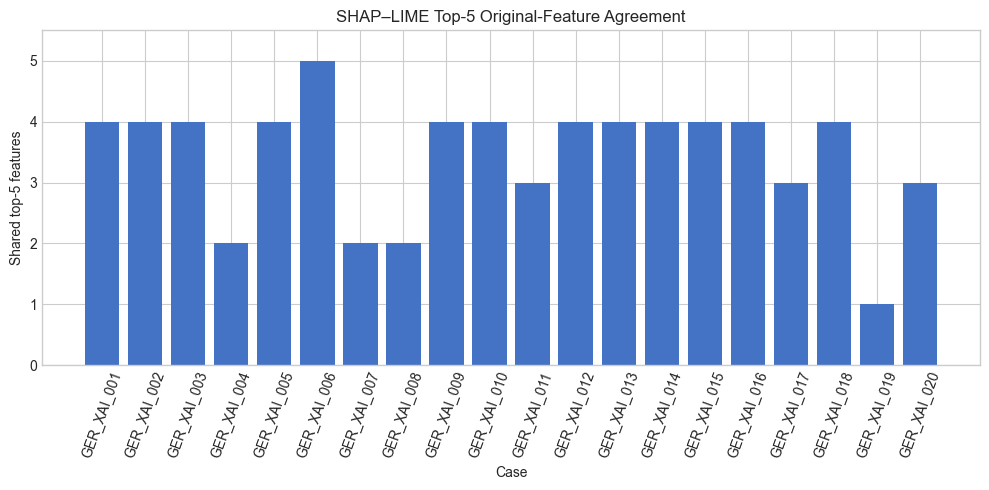

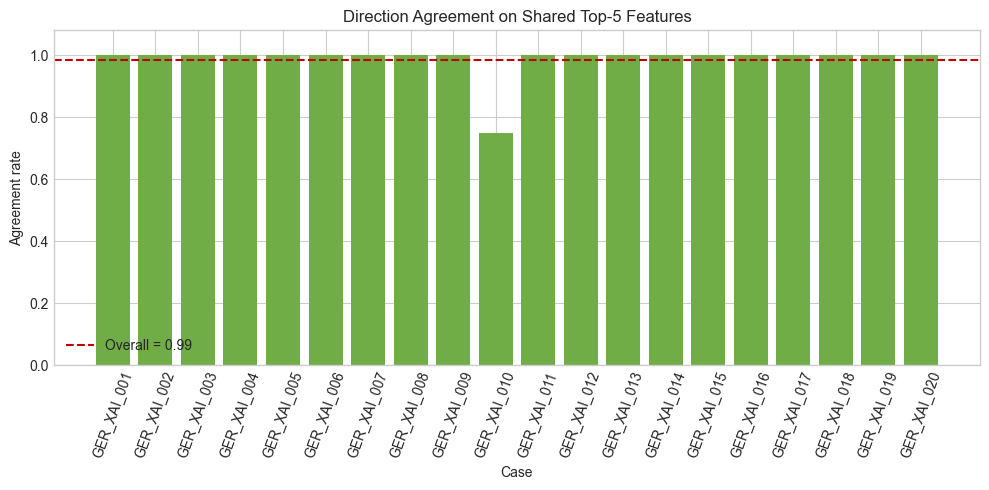

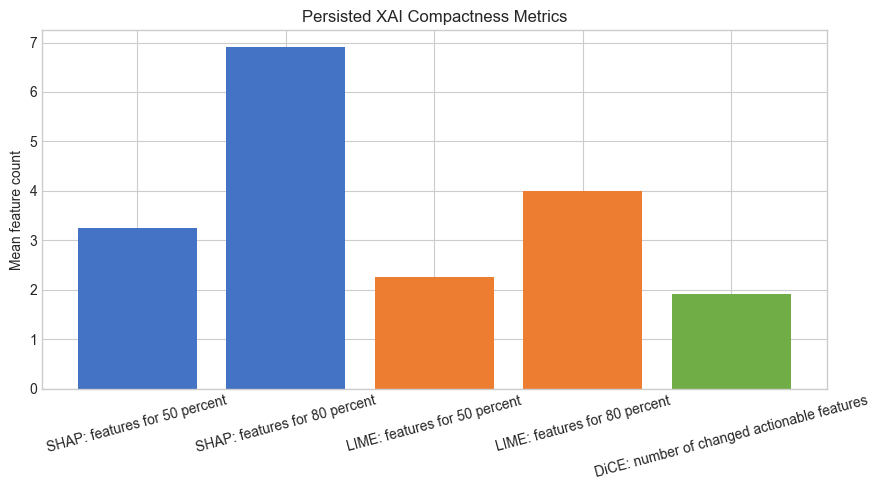

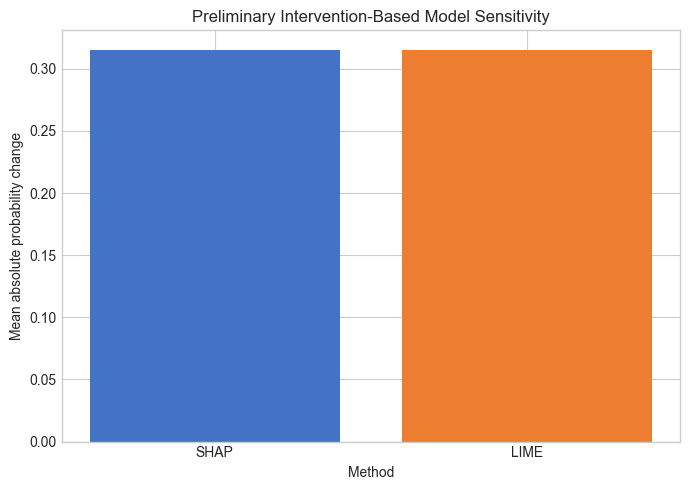

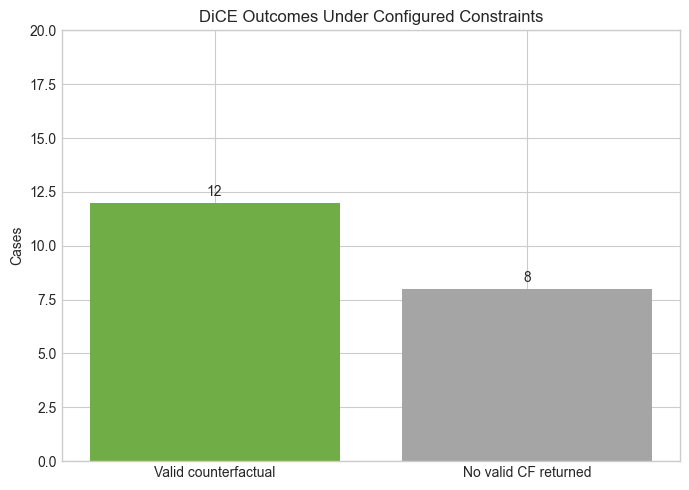

In [10]:
plot_paths = []

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(agreement.case_id, agreement.top_5_overlap_count, color="#4472C4")
ax.set(title="SHAP–LIME Top-5 Original-Feature Agreement", ylabel="Shared top-5 features", xlabel="Case")
ax.set_ylim(0, 5.5); ax.tick_params(axis="x", rotation=70)
fig.tight_layout(); path = PLOT_DIR / "german_credit_xai_shap_lime_top5_agreement.png"; fig.savefig(path, dpi=300); plt.show(); plot_paths.append(path)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(direction.case_id, direction.direction_agreement_rate, color="#70AD47")
ax.axhline(overall_direction, color="#C00000", linestyle="--", label=f"Overall = {overall_direction:.2f}")
ax.set(title="Direction Agreement on Shared Top-5 Features", ylabel="Agreement rate", xlabel="Case", ylim=(0, 1.08))
ax.tick_params(axis="x", rotation=70); ax.legend()
fig.tight_layout(); path = PLOT_DIR / "german_credit_xai_direction_agreement.png"; fig.savefig(path, dpi=300); plt.show(); plot_paths.append(path)

fig, ax = plt.subplots(figsize=(9, 5))
labels = [f"{r.method}: {r.metric.replace('_', ' ')}" for r in sparsity_comparison.itertuples()]
ax.bar(labels, sparsity_comparison["mean"], color=["#4472C4", "#4472C4", "#ED7D31", "#ED7D31", "#70AD47"])
ax.set(title="Persisted XAI Compactness Metrics", ylabel="Mean feature count"); ax.tick_params(axis="x", rotation=15)
fig.tight_layout(); path = PLOT_DIR / "german_credit_xai_sparsity_comparison.png"; fig.savefig(path, dpi=300); plt.show(); plot_paths.append(path)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(faithfulness_comparison.method, faithfulness_comparison.mean_absolute_score_change, color=["#4472C4", "#ED7D31"])
ax.set(title="Preliminary Intervention-Based Model Sensitivity", ylabel="Mean absolute probability change", xlabel="Method")
fig.tight_layout(); path = PLOT_DIR / "german_credit_xai_faithfulness_comparison.png"; fig.savefig(path, dpi=300); plt.show(); plot_paths.append(path)

outcome_counts = pd.Series({"Valid counterfactual": valid_cf_count, "No valid CF returned": len(cases) - valid_cf_count})
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(outcome_counts.index, outcome_counts.values, color=["#70AD47", "#A5A5A5"])
ax.set(title="DiCE Outcomes Under Configured Constraints", ylabel="Cases", ylim=(0, 20))
for i, value in enumerate(outcome_counts): ax.text(i, value + 0.3, str(value), ha="center")
fig.tight_layout(); path = PLOT_DIR / "german_credit_xai_dice_outcomes.png"; fig.savefig(path, dpi=300); plt.show(); plot_paths.append(path)

## Interpretation of Cross-Method XAI Evaluation

SHAP provides additive local and global model attribution, supported here by its persisted perturbation-stability and sensitivity diagnostics. LIME provides local surrogate explanations; its agreement with SHAP must be read alongside same-seed reproducibility and local fidelity limitations.

DiCE addresses a different question by finding actionable class-changing examples under three conservative feature constraints. Successful examples can be assessed through sparsity and proximity, while a search returning no valid example is not evidence that no counterfactual exists.

## 10. Final metric summary and metadata

The summary collects the main persisted evaluation measures with short, method-specific interpretations.

In [11]:
def summary_row(category, metric, method, value, n, interpretation):
    return {"category": category, "metric": metric, "method": method, "value": value,
            "cases_evaluated": n, "interpretation": interpretation}

summary_rows = [
    summary_row("agreement", "top_1_agreement_rate", "SHAP–LIME", agreement.top_1_agreement.mean(), 20, "Same leading original feature"),
    summary_row("agreement", "mean_top_5_overlap", "SHAP–LIME", agreement.top_5_overlap_count.mean(), 20, "Mean shared top-five features"),
    summary_row("agreement", "mean_top_5_jaccard", "SHAP–LIME", agreement.top_5_jaccard.mean(), 20, "Set agreement at top five"),
    summary_row("direction", "overall_direction_agreement_rate", "SHAP–LIME", overall_direction, 20, "Sign agreement on shared features"),
]
for row in sparsity_comparison.itertuples():
    summary_rows.append(summary_row("sparsity", row.metric, row.method, row.mean, row.count, "Method-specific compactness"))
for row in stability_comparison.itertuples():
    summary_rows.append(summary_row("stability", "mean_top_5_overlap", row.method, row.mean_top_5_overlap, row.cases_tested, row.diagnostic_type))
for row in faithfulness_comparison.itertuples():
    summary_rows.append(summary_row("sensitivity", "mean_absolute_score_change", row.method, row.mean_absolute_score_change, row.cases_tested,
                                    "Preliminary intervention-based model sensitivity"))
for row in lime_fidelity_summary.itertuples():
    summary_rows.append(summary_row("local fidelity", row.metric, "LIME", row.mean, row.count, "Persisted local surrogate fit"))
summary_rows.extend([
    summary_row("counterfactual", "availability_rate", "DiCE", dice_availability, 20, "Valid CF returned under configured constraints"),
    summary_row("counterfactual", "mean_changed_actionable_features", "DiCE", dice_eval.number_of_changed_actionable_features.mean(), valid_cf_count, "Mean changes among valid CFs"),
])
xai_evaluation_summary = pd.DataFrame(summary_rows)
xai_evaluation_summary.to_csv(ARTIFACT_DIR / "xai_evaluation_summary.csv", index=False)

created_artifacts = [
    "xai_shap_lime_agreement.csv", "xai_direction_agreement.csv", "xai_sparsity_comparison.csv",
    "xai_stability_comparison.csv", "xai_faithfulness_comparison.csv", "xai_lime_local_fidelity_summary.csv",
    "xai_dice_evaluation.csv", "xai_cross_method_case_summary.csv", "xai_case_type_comparison.csv",
    "xai_evaluation_summary.csv", "xai_evaluation_metadata.json",
]
metadata = {
    "dataset": dice_metadata["dataset"], "evaluation_case_count": len(cases),
    "shap_case_count": shap_top.case_id.nunique(), "lime_case_count": lime_top.case_id.nunique(),
    "dice_status_case_count": dice_status.case_id.nunique(), "valid_dice_counterfactual_count": valid_cf_count,
    "artifacts_used": list(required), "artifacts_created": created_artifacts,
    "plots_created": [path.name for path in plot_paths], "evaluation_timestamp": datetime.now(timezone.utc).isoformat(),
    "model_retrained": False, "preprocessor_refitted": False, "shap_regenerated": False,
    "lime_regenerated": False, "dice_regenerated": False,
}
with open(ARTIFACT_DIR / "xai_evaluation_metadata.json", "w", encoding="utf-8") as handle:
    json.dump(metadata, handle, indent=2)
display(xai_evaluation_summary)

,category,metric,method,value,cases_evaluated,interpretation
0,agreement,top_1_agreement_rate,SHAP–LIME,0.750000,20,Same leading original feature
1,agreement,mean_top_5_overlap,SHAP–LIME,3.450000,20,Mean shared top-five features
2,agreement,mean_top_5_jaccard,SHAP–LIME,0.557341,20,Set agreement at top five
3,direction,overall_direction_agreement_rate,SHAP–LIME,0.985507,20,Sign agreement on shared features
4,sparsity,features_for_50_percent,SHAP,3.250000,20,Method-specific compactness
5,sparsity,features_for_80_percent,SHAP,6.900000,20,Method-specific compactness
6,sparsity,features_for_50_percent,LIME,2.250000,20,Method-specific compactness
7,sparsity,features_for_80_percent,LIME,4.000000,20,Method-specific compactness
8,sparsity,number_of_changed_actionable_features,DiCE,1.916667,12,Method-specific compactness
9,stability,mean_top_5_overlap,SHAP,5.000000,5,small deterministic feature-perturbation stabi...


## 11. Final quality checks

These checks confirm cohort alignment, persisted artifact completeness, probability consistency, and the absence of any regeneration step.

In [12]:
assert len(cases) == cases.case_id.nunique() == 20
assert shap_top.case_id.nunique() == lime_top.case_id.nunique() == dice_status.case_id.nunique() == 20
assert len(shap_top) == len(lime_top) == 100
assert len(shap_stability) == len(lime_stability) == 5
assert len(shap_faithfulness) == len(lime_faithfulness) == 5
assert valid_cf_count == int(dice_metadata["final_valid_counterfactual_count"])
assert len(dice_changes) == valid_cf_count * 3
assert len(cross_method) == 20 and cross_method.case_id.is_unique
assert np.allclose(cross_method.predicted_probability, cases.set_index("case_id").loc[cross_method.case_id, "predicted_probability"])
assert np.allclose(shap_top.groupby("case_id").predicted_probability.first().loc[cases.case_id], cases.predicted_probability)
assert np.allclose(lime_top.groupby("case_id").predicted_probability.first().loc[cases.case_id], cases.predicted_probability)
assert dice_first_pass.generation_status.eq("timeout").sum() == 0
assert dice_status.retry_performed.astype(bool).sum() == 0

print(f"XAI cases evaluated: {len(cases)}")
print(f"SHAP cases: {shap_top.case_id.nunique()}")
print(f"LIME cases: {lime_top.case_id.nunique()}")
print(f"DiCE status cases: {dice_status.case_id.nunique()}")
print(f"Valid DiCE counterfactuals: {valid_cf_count}")
print(f"SHAP-LIME top-1 agreement: {agreement.top_1_agreement.sum()} / 20")
print(f"Mean SHAP-LIME top-3 overlap: {agreement.top_3_overlap_count.mean():.3f}")
print(f"Mean SHAP-LIME top-3 Jaccard: {agreement.top_3_jaccard.mean():.3f}")
print(f"Mean SHAP-LIME top-5 overlap: {agreement.top_5_overlap_count.mean():.3f}")
print(f"Mean SHAP-LIME top-5 Jaccard: {agreement.top_5_jaccard.mean():.3f}")
print(f"Overall directional agreement: {overall_direction:.3f}")
print(f"SHAP preliminary stability mean overlap: {stability_comparison.loc[stability_comparison.method.eq('SHAP'), 'mean_top_5_overlap'].iloc[0]:.3f}")
print(f"LIME same-seed reproducibility mean overlap: {stability_comparison.loc[stability_comparison.method.eq('LIME'), 'mean_top_5_overlap'].iloc[0]:.3f}")
print(f"SHAP preliminary sensitivity mean score change: {shap_faithfulness.absolute_score_change.mean():.6f}")
print(f"LIME preliminary sensitivity mean score change: {lime_faithfulness.absolute_score_change.mean():.6f}")
print(f"LIME mean local fidelity R2: {lime_fidelity.local_fidelity_r2.mean():.6f}")
print(f"LIME mean absolute local prediction error: {lime_fidelity.absolute_local_prediction_error.mean():.6f}")
print(f"DiCE counterfactual availability: {valid_cf_count} / 20 ({dice_availability:.1%})")
print(f"Mean changed actionable features for valid DiCE CFs: {dice_eval.number_of_changed_actionable_features.mean():.3f}")
print(f"Mean DiCE proximity score: {dice_eval.proximity_score.mean():.6f}")
print("Model retrained: False")
print("Preprocessor refitted: False")
print("SHAP regenerated: False")
print("LIME regenerated: False")
print("DiCE regenerated: False")

XAI cases evaluated: 20
SHAP cases: 20
LIME cases: 20
DiCE status cases: 20
Valid DiCE counterfactuals: 12
SHAP-LIME top-1 agreement: 15 / 20
Mean SHAP-LIME top-3 overlap: 1.800
Mean SHAP-LIME top-3 Jaccard: 0.500
Mean SHAP-LIME top-5 overlap: 3.450
Mean SHAP-LIME top-5 Jaccard: 0.557
Overall directional agreement: 0.986
SHAP preliminary stability mean overlap: 5.000
LIME same-seed reproducibility mean overlap: 5.000
SHAP preliminary sensitivity mean score change: 0.315064
LIME preliminary sensitivity mean score change: 0.315064
LIME mean local fidelity R2: 0.319525
LIME mean absolute local prediction error: 0.144864
DiCE counterfactual availability: 12 / 20 (60.0%)
Mean changed actionable features for valid DiCE CFs: 1.917
Mean DiCE proximity score: 0.180020
Model retrained: False
Preprocessor refitted: False
SHAP regenerated: False
LIME regenerated: False
DiCE regenerated: False
